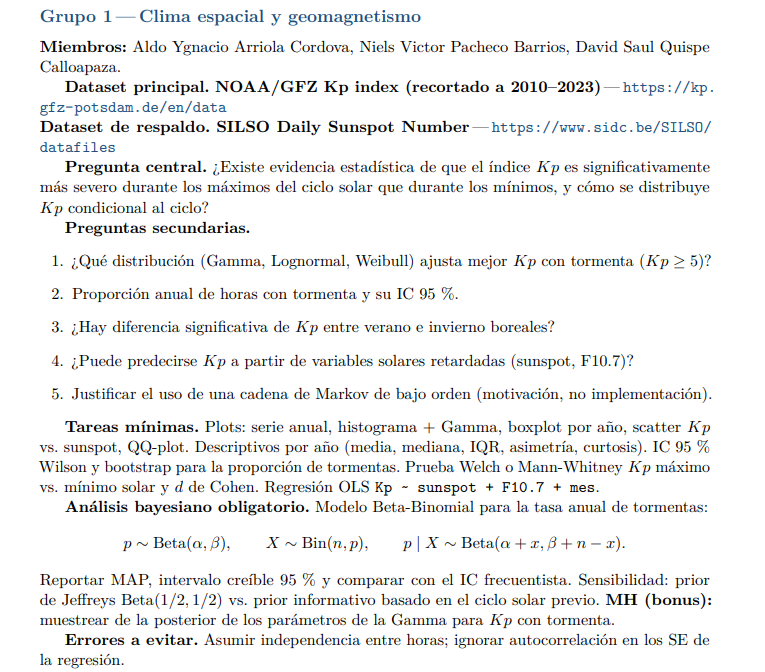

In [4]:
from datetime import datetime, timedelta
import time

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.stats.sandwich_covariance import cov_hac

In [5]:
# Configuración estética global para el Notebook
plt.rcParams.update({
    "figure.facecolor": "white",    
    "axes.facecolor": "white",      
    "axes.edgecolor": "#333333",      
    "axes.linewidth": 0.8,
    "axes.grid": True,         
    "grid.color": "#e2e2e2",          
    "grid.linestyle": "--",      
    "grid.alpha": 0.7,
    "font.family": "sans-serif",     
    "font.size": 11,
    "axes.labelsize": 12,              
    "axes.titlesize": 14,              
    "xtick.labelsize": 10,             
    "ytick.labelsize": 10,            
    "figure.dpi": 100                  
})

## Loading the data

In [6]:
# geomagnetic and solar indices
# days : number of days since 1932-01-01
# days_m : mean day of days
# BSR : Bartels Solar Rotation Number, it changes every 27 days
# dB : specific day in the 1 - 27 range of the Bartels Solar Rotation Number
# Kp_i : pertubation index for the 3-hour interval i (00, 03, 06, 09, 12, 15, 18, 21) cuasi log scale 0 - 9
# ap_i : planetary index for the 3-hour interval i (00, 03, 06, 09, 12, 15, 18, 21), in nT, linear scale 0 - 400
# Ap : daily mean planetary index, in nT, linear scale 0 - 400....
# SN : Sunspot number
# D : if D = 2, we are working with definitve data, valided data

df_geom = pd.read_csv("data/geomagnetic-solarindices.txt", sep=r"\s+",header=None)
df_geom.columns = [
                    "year", "month", "day", "days", "days_m", 
                    "BSR", "dB", "Kp_00", "Kp_03", "Kp_06", 
                    "Kp_09", "Kp_12", "Kp_15", "Kp_18", "Kp_21", 
                    "ap_00","ap_03","ap_06","ap_09","ap_12","ap_15", 
                    "ap_18","ap_21","Ap", "SN", "F10.7obs", "F10.7adj", "D"
                ]
df_geom["date"] = pd.to_datetime(df_geom[["year", "month", "day"]])
# also, we might need the daily Kp (average) -----> NOT OK, kp is a cuasi log scale
# df_geom["Kp_daily"] = df_geom[["Kp_00", "Kp_03", 
#                                "Kp_06", "Kp_09", 
#                                "Kp_12", "Kp_15", 
#                                "Kp_18", "Kp_21"]].mean(axis=1)
print("Kp and solar indices Dataset")
df_geom.head()

Kp and solar indices Dataset


,year,month,day,days,days_m,BSR,dB,Kp_00,Kp_03,Kp_06,...,ap_12,ap_15,ap_18,ap_21,Ap,SN,F10.7obs,F10.7adj,D,date
0,2010,1,1,28490,28490.5,2407,15,0.000,0.000,0.000,...,0,0,0,4,0,18,75.2,72.7,2,2010-01-01
1,2010,1,2,28491,28491.5,2407,16,0.000,0.000,0.333,...,0,2,2,2,1,21,78.0,75.4,2,2010-01-02
2,2010,1,3,28492,28492.5,2407,17,0.333,1.333,0.667,...,6,3,0,2,4,16,76.4,73.8,2,2010-01-03
3,2010,1,4,28493,28493.5,2407,18,0.333,0.000,1.333,...,2,0,2,0,2,15,73.0,70.6,2,2010-01-04
4,2010,1,5,28494,28494.5,2407,19,0.000,0.000,0.000,...,3,4,2,0,1,10,76.8,74.3,2,2010-01-05


In [7]:
# sunspot number dataset
df_sn = pd.read_csv("data/SN_d_tot_V2.0.txt", sep=r"\s+", header=None)
df_sn.columns = ["year", "month", "day", "date_year_fraction", "daily_total_sn", "daily_std_sn", "obs_number"]#, "indicator"]
# only years from 2010 to 2023
df_sn = df_sn[(2010<=df_sn["year"]) & (df_sn["year"]<=2023)  ]
df_sn["date"] = pd.to_datetime(df_sn[["year", "month", "day"]])
print("Sunspot Number Dataset")
df_sn.head()

Sunspot Number Dataset


,year,month,day,date_year_fraction,daily_total_sn,daily_std_sn,obs_number,date
70127,2010,1,1,2010.001,18,1.3,15,2010-01-01
70128,2010,1,2,2010.004,21,1.2,16,2010-01-02
70129,2010,1,3,2010.007,16,2.0,17,2010-01-03
70130,2010,1,4,2010.010,15,0.8,14,2010-01-04
70131,2010,1,5,2010.012,10,2.3,17,2010-01-05


In [8]:
kp_cols = ["Kp_00", "Kp_03", "Kp_06", "Kp_09", "Kp_12", "Kp_15", "Kp_18", "Kp_21"]
df_kp = pd.melt(df_geom, id_vars=["year", "month", "day"], value_vars=kp_cols, var_name="hour_str", value_name="Kp")
df_kp["hour"] = df_kp["hour_str"].str.replace("Kp_", "")
df_kp["datetime"] = pd.to_datetime(
    df_kp["year"].astype(str) + "-" + df_kp["month"].astype(str) + "-" + df_kp["day"].astype(str)
    + " " + df_kp["hour"]+ ":00:00" 
    )
df_kp = df_kp[["datetime", "Kp"]].sort_values("datetime").reset_index(drop=True)
df_kp.head()

,datetime,Kp
0,2010-01-01 00:00:00,0.0
1,2010-01-01 03:00:00,0.0
2,2010-01-01 06:00:00,0.0
3,2010-01-01 09:00:00,0.0
4,2010-01-01 12:00:00,0.0


## Tareas mínimas
### a)  Serie anual

Se logra observar, visuzalmente, una correlacion entre Kp y SN.


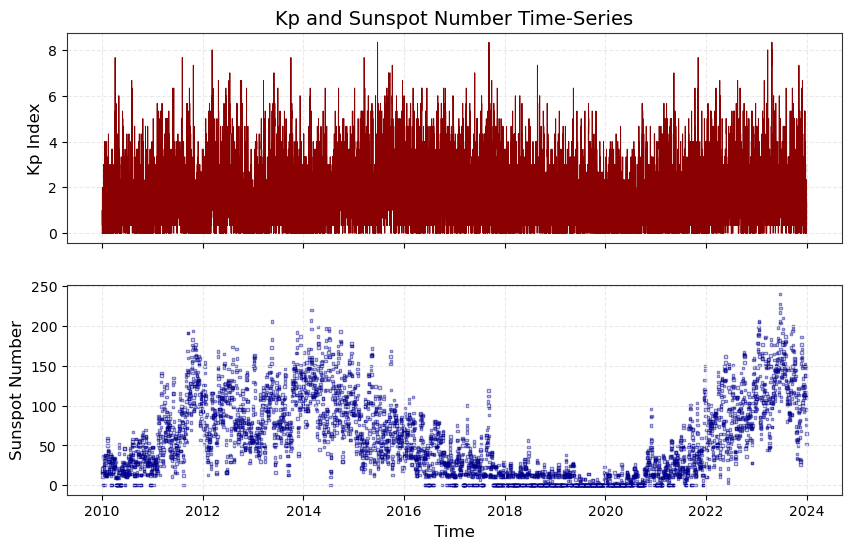

In [9]:
fig, axs = plt.subplots(nrows=2, figsize=(10,6), sharex=True)
ax = axs[0]
ax.step(df_kp["datetime"], df_kp["Kp"], color="darkred", lw=0.7)
#ax.scatter(df_kp["datetime"], df_kp["Kp"], marker="o", facecolor="none", edgecolor="darkred", s=3, alpha=0.5)
ax.set_ylabel("Kp Index")
ax.set_title("Kp and Sunspot Number Time-Series")
ax = axs[1]
ax.scatter(df_geom["date"], df_geom["SN"], marker="s", facecolor="none", edgecolor="darkblue", s=3, alpha=0.5)
ax.set_ylabel("Sunspot Number")

plt.xlabel("Time")

print("Se logra observar, visuzalmente, una correlacion entre Kp y SN.")

In [10]:
df_geom.head()

,year,month,day,days,days_m,BSR,dB,Kp_00,Kp_03,Kp_06,...,ap_12,ap_15,ap_18,ap_21,Ap,SN,F10.7obs,F10.7adj,D,date
0,2010,1,1,28490,28490.5,2407,15,0.000,0.000,0.000,...,0,0,0,4,0,18,75.2,72.7,2,2010-01-01
1,2010,1,2,28491,28491.5,2407,16,0.000,0.000,0.333,...,0,2,2,2,1,21,78.0,75.4,2,2010-01-02
2,2010,1,3,28492,28492.5,2407,17,0.333,1.333,0.667,...,6,3,0,2,4,16,76.4,73.8,2,2010-01-03
3,2010,1,4,28493,28493.5,2407,18,0.333,0.000,1.333,...,2,0,2,0,2,15,73.0,70.6,2,2010-01-04
4,2010,1,5,28494,28494.5,2407,19,0.000,0.000,0.000,...,3,4,2,0,1,10,76.8,74.3,2,2010-01-05


## Tareas mínimas
### Boxplots

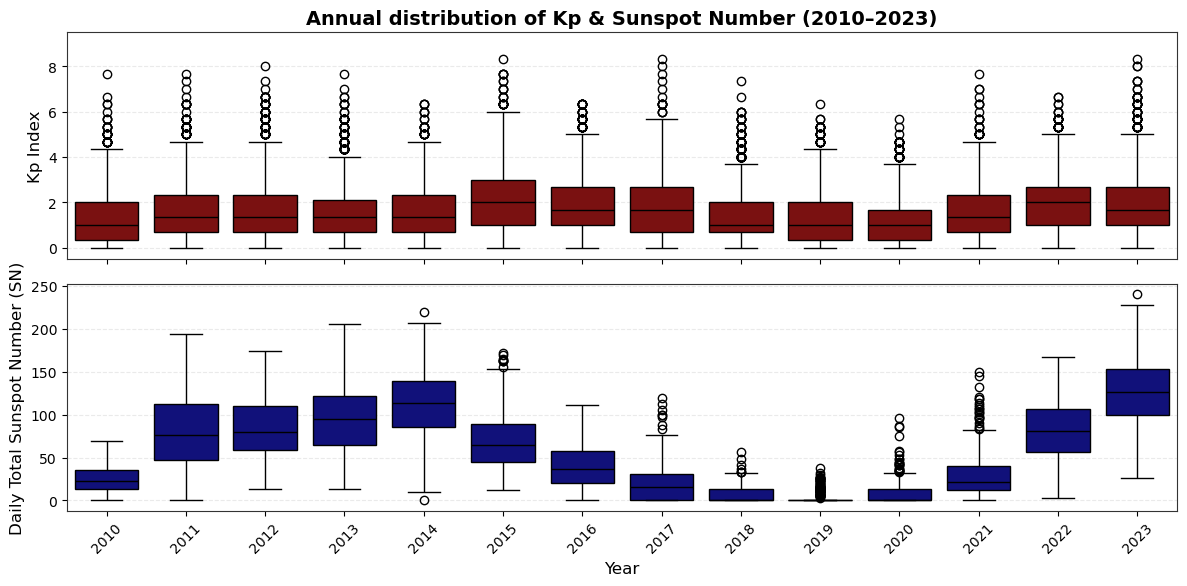

In [11]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 6), sharex=True)

ax = axs[0]

# Boxplot per year
df_kp['year'] = df_kp['datetime'].dt.year

sns.boxplot(data=df_kp, x="year", y="Kp", color = 'darkred', linecolor = 'black', ax=ax)

ax.set_title("Annual distribution of Kp & Sunspot Number (2010–2023)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Kp Index", fontsize=12)
ax.set_ylim(-0.5, 9.5)
# plt.xticks(rotation=45)

ax = axs[1]
sns.boxplot(data=df_sn, x="year", y="daily_total_sn", color = 'darkblue', linecolor = 'black', ax=ax)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Daily Total Sunspot Number (SN)", fontsize=12)
#plt.ylim(-0.5, 9.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

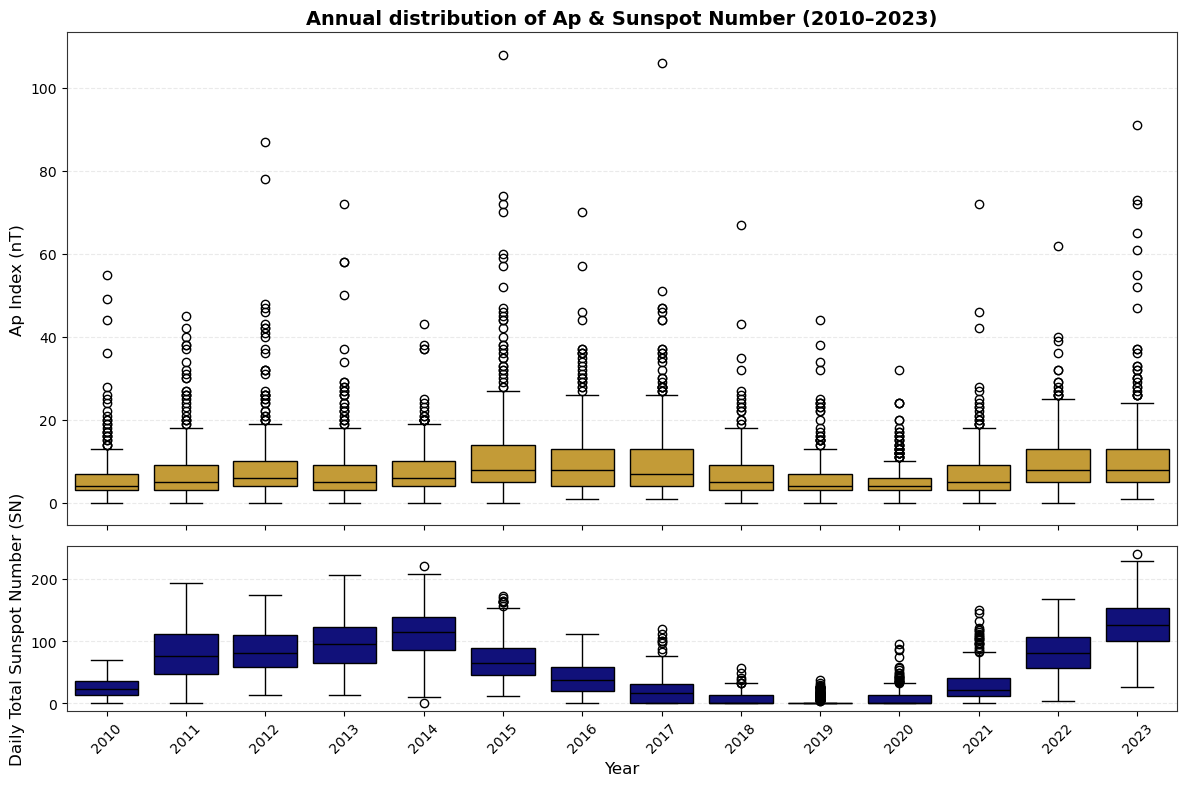

In [93]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax = axs[0]
sns.boxplot(data=df_geom, x="year", y="Ap", color='goldenrod', linecolor='black', ax=ax)
ax.set_title("Annual distribution of Ap & Sunspot Number (2010–2023)", fontsize=14, fontweight="bold")
ax.set_ylabel("Ap Index (nT)", fontsize=12)

ax = axs[1]
sns.boxplot(data=df_sn, x="year", y="daily_total_sn", color='darkblue', linecolor='black', ax=ax)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Daily Total Sunspot Number (SN)", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Tareas mínimas
### Descriptivos por año

In [54]:
# Funcion para el rango intercuartilico (IQR)
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

df_kp["year"] = df_kp["datetime"].dt.year
descriptivos_anuales = df_kp.groupby("year")["Kp"].agg(
    Media='mean',
    Mediana='median',
    IQR=iqr,
    Asimetria=lambda x : x.skew(),
    Curtosis=lambda x: x.kurt()
).reset_index()

print("--- Estadística Descriptiva del Índice Kp por Año ---")
print("-- Observación física :\t El ínidice Kp se mide en escala cuasi-logaritmica, por lo que\n" \
"\t \t \t trabajar el promedio no sería la mejor opción.")
print(descriptivos_anuales.to_string(index=False, float_format=lambda x: f"{x:.3f}"))



--- Estadística Descriptiva del Índice Kp por Año ---
-- Observación física :	 El ínidice Kp se mide en escala cuasi-logaritmica, por lo que
	 	 	 trabajar el promedio no sería la mejor opción.
 year  Media  Mediana   IQR  Asimetria  Curtosis
 2010  1.253    1.000 1.667      1.191     1.607
 2011  1.484    1.333 1.666      1.122     1.497
 2012  1.673    1.333 1.666      1.040     1.126
 2013  1.478    1.333 1.416      1.075     1.074
 2014  1.627    1.333 1.666      0.752     0.365
 2015  2.114    2.000 2.000      0.755     0.571
 2016  1.946    1.667 1.667      0.633    -0.101
 2017  1.885    1.667 2.000      0.737     0.226
 2018  1.419    1.000 1.333      1.058     1.084
 2019  1.308    1.000 1.667      1.083     1.126
 2020  1.172    1.000 1.334      1.063     0.831
 2021  1.466    1.333 1.666      1.019     1.064
 2022  1.954    2.000 1.667      0.537    -0.105
 2023  1.967    1.667 1.667      0.891     1.065


--- Estadística Descriptiva del Índice Ap por Año ---
 year  Media  Mediana  Desviacion   IQR  Asimetria  Curtosis
 2010  5.962    4.000       6.178 4.000      3.933    22.278
 2011  7.485    5.000       7.171 6.000      2.527     7.498
 2012  9.063    6.000       9.903 6.000      3.561    18.616
 2013  7.584    5.000       8.280 6.000      3.610    18.816
 2014  7.718    6.000       5.783 6.000      2.349     8.502
 2015 12.238    8.000      12.458 9.000      3.165    14.465
 2016 10.478    8.000       8.979 9.000      2.265     7.952
 2017 10.334    7.000      10.296 9.000      3.421    21.732
 2018  6.863    5.000       6.398 6.000      3.800    25.097
 2019  6.063    4.000       5.419 4.000      3.096    13.509
 2020  5.243    4.000       4.162 3.000      2.378     8.083
 2021  7.164    5.000       6.642 6.000      4.096    29.359
 2022 10.093    8.000       7.436 8.000      2.002     7.373
 2023 10.819    8.000      10.770 8.000      3.550    17.217


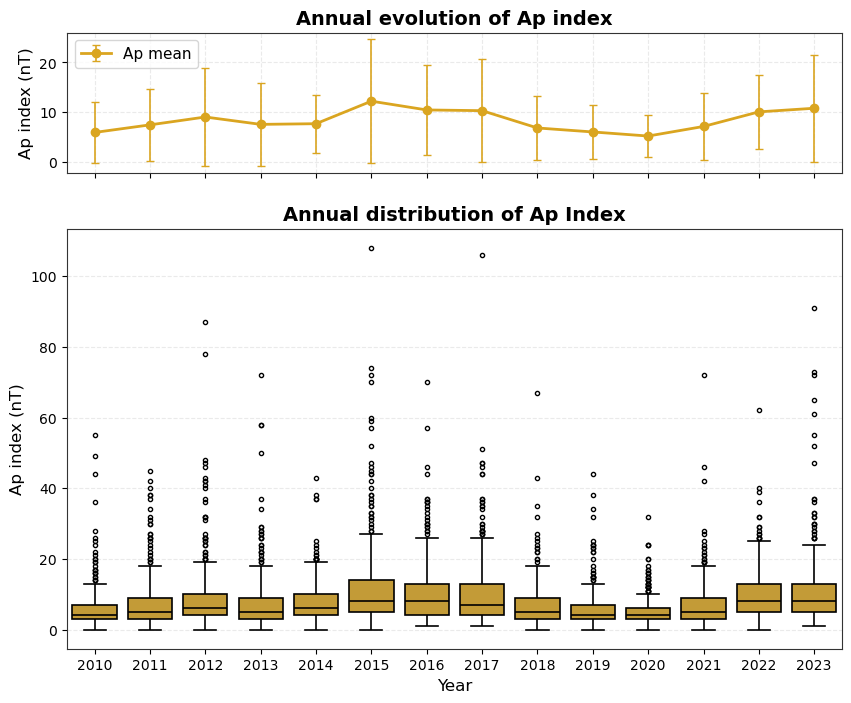

In [86]:
descriptivos_Ap = df_geom.groupby("year")["Ap"].agg(
    Media='mean',
    Mediana='median',
    Desviacion='std',
    IQR=iqr,
    Asimetria=lambda x: x.skew(),
    Curtosis=lambda x: x.kurt()
).reset_index()

print("--- Estadística Descriptiva del Índice Ap por Año ---")
print(descriptivos_Ap.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [1, 3]})
axs[0].errorbar(
    x=range(len(descriptivos_Ap["year"])), 
    y=descriptivos_Ap["Media"], 
    yerr=descriptivos_Ap["Desviacion"], # Asignamos la columna de desviación como error
    fmt='o-',                           # Línea con marcadores circulares
    color='goldenrod', 
    ecolor='goldenrod',                   # Color gris para las barras de error
    elinewidth=1.2,                     # Grosor de la barra
    capsize=3,                          # Topes de las barras
    lw=2, 
    markersize=6,
    label='Ap mean'
)
axs[0].set_title("Annual evolution of Ap index", fontweight="bold")
axs[0].set_ylabel("Ap index (nT)")
axs[0].legend(loc="upper left")


sns.boxplot(
    data=df_geom, 
    x="year", 
    y="Ap", 
    ax=axs[1],
    color='goldenrod',     
    linecolor='black', 
    linewidth=1.2,
    fliersize=3          
)

axs[1].set_title("Annual distribution of Ap Index", fontweight="bold")
axs[1].set_ylabel("Ap index (nT)")
axs[1].set_xlabel("Year")


plt.show()

In [12]:
# Distribición Conjunta: se requiere Kp y SN alineados en X
# dado que Kp es una medida cuasi logaritmica y equivalente lieal es la variable Ap (promedio diario)


## Tareas mínimas
### b) Histogramas

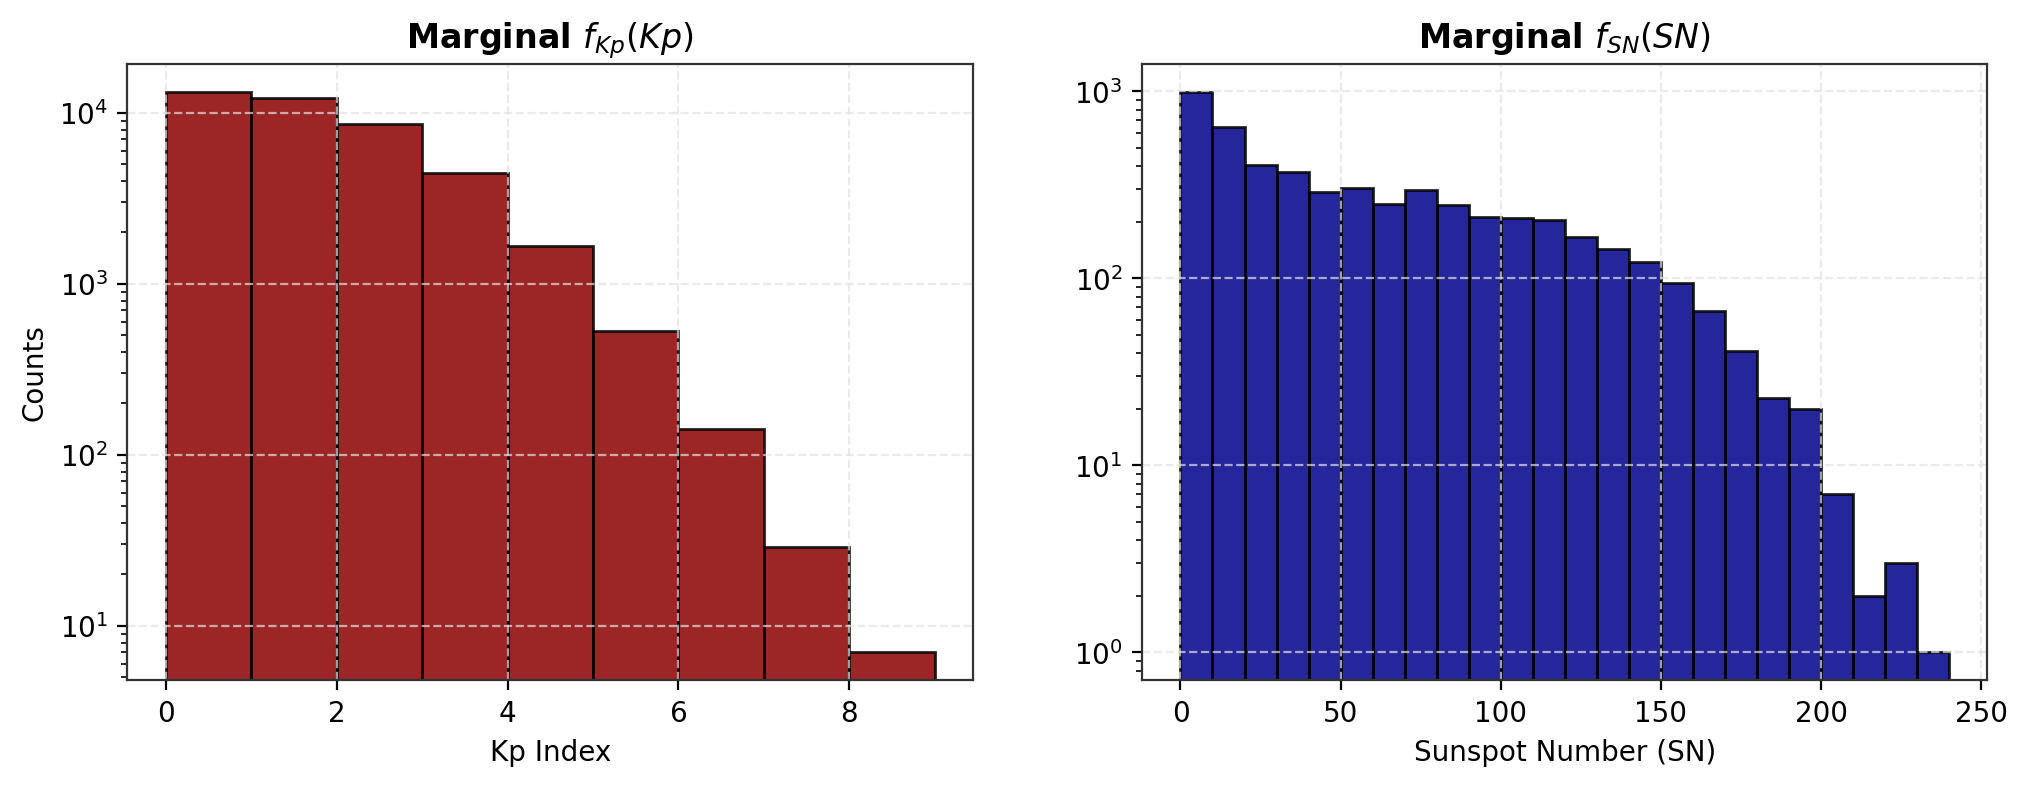

Para el índica Kp, hay muchos valores entre 0 y 3, esto representa un contexto 'calmado'


<Figure size 640x480 with 0 Axes>

In [102]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi = 200)

bins = np.arange(0, max(df_kp["Kp"])+1, 1)
axs[0].hist(df_kp["Kp"], bins = bins, color = 'darkred', density = False, edgecolor = 'black', alpha = 0.85,linewidth=1)
axs[0].set_title(r"Marginal $f_{Kp}(Kp)$", fontsize=12, fontweight="bold")
axs[0].set_xlabel("Kp Index", fontsize=10)
axs[0].set_ylabel("Counts", fontsize=10)
axs[0].set_yscale("log")

bins = np.arange(0, max(df_sn["daily_total_sn"])+1, 10)
axs[1].hist(df_sn["daily_total_sn"], bins = bins, color = 'darkblue', density = False, edgecolor = 'black', alpha = 0.85,linewidth=1)
axs[1].set_title(r"Marginal $f_{SN}(SN)$", fontsize=12, fontweight="bold")
axs[1].set_xlabel(r"Sunspot Number (SN)", fontsize=10)
#axs[1].set_ylabel("Density", fontsize=10)
axs[1].set_yscale("log")

plt.show()

# fig, ax = plt.subplots()
print("Para el índica Kp, hay muchos valores entre 0 y 3, esto representa un contexto 'calmado'")

plt.tight_layout()

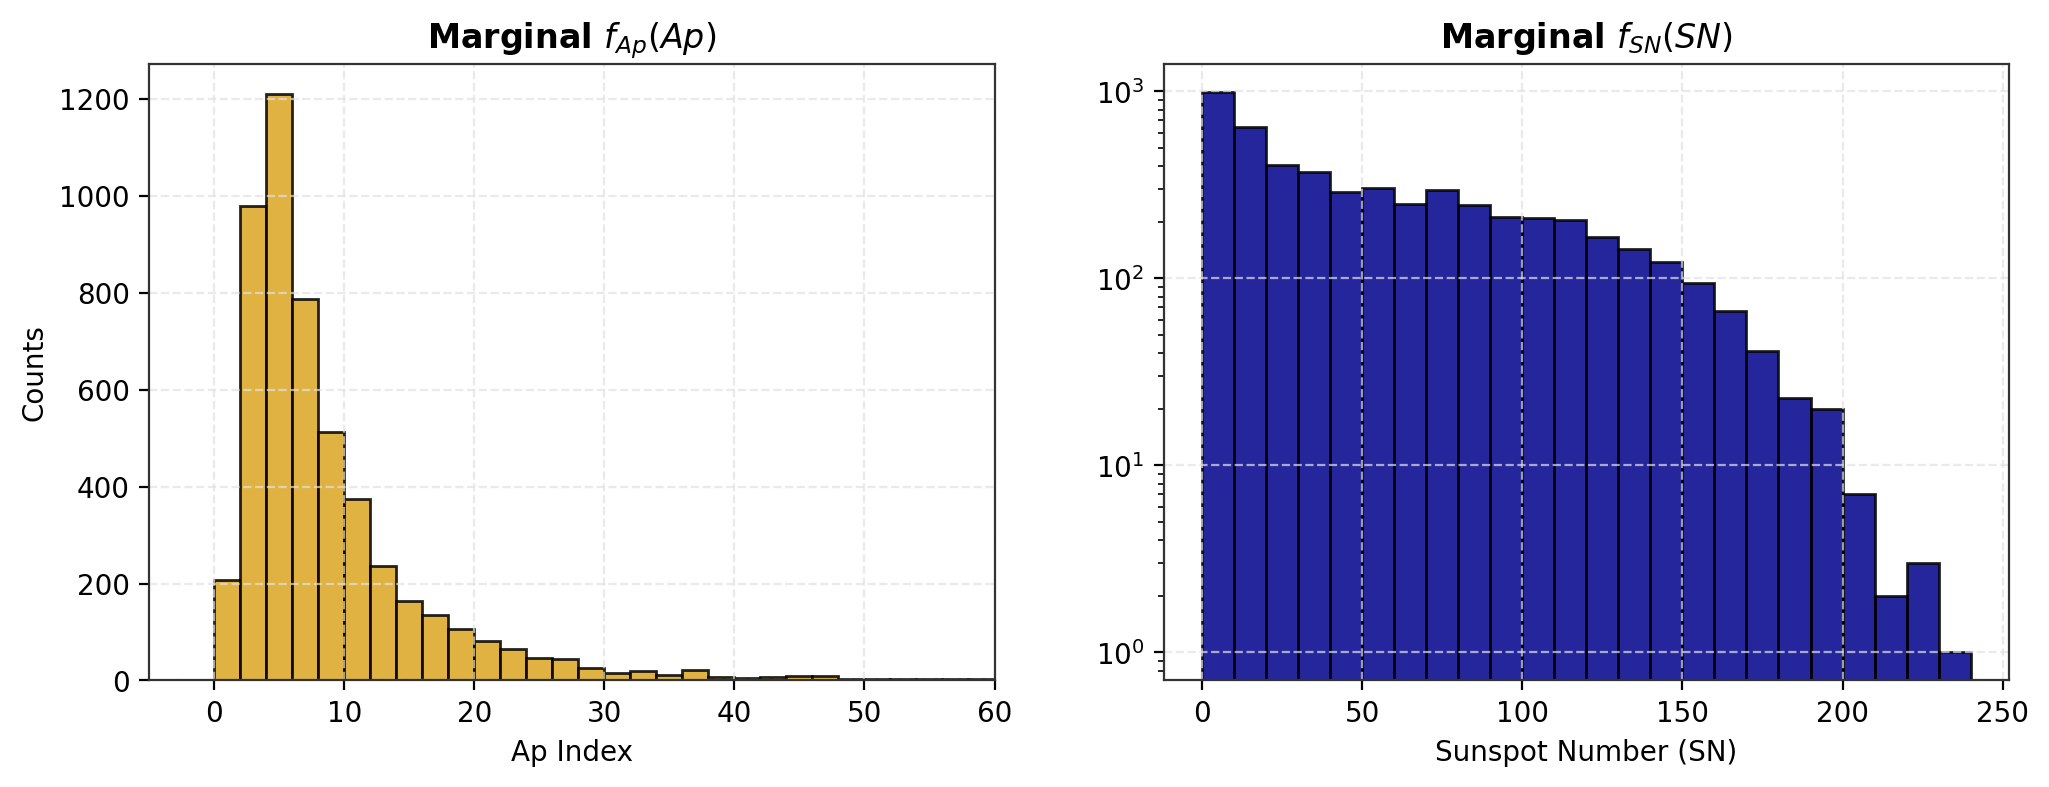

<Figure size 640x480 with 0 Axes>

In [109]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi = 200)

bins = np.arange(0, max(df_geom["Ap"])+1, 2)
axs[0].hist(df_geom["Ap"], bins = bins, color = 'goldenrod', density = False, edgecolor = 'black', alpha = 0.85,linewidth=1)
axs[0].set_title(r"Marginal $f_{Ap}(Ap)$", fontsize=12, fontweight="bold")
axs[0].set_xlabel("Ap Index", fontsize=10)
axs[0].set_ylabel("Counts", fontsize=10)
axs[0].set_xlim(-5,60)
#axs[0].set_yscale("log")

bins = np.arange(0, max(df_sn["daily_total_sn"])+1, 10)
axs[1].hist(df_sn["daily_total_sn"], bins = bins, color = 'darkblue', density = False, edgecolor = 'black', alpha = 0.85,linewidth=1)
axs[1].set_title(r"Marginal $f_{SN}(SN)$", fontsize=12, fontweight="bold")
axs[1].set_xlabel(r"Sunspot Number (SN)", fontsize=10)
#axs[1].set_ylabel("Density", fontsize=10)
axs[1].set_yscale("log")

plt.show()

# fig, ax = plt.subplots()
#print("Para el índica Kp, hay muchos valores entre 0 y 3, esto representa un contexto 'calmado'")

plt.tight_layout()

## Tareas mínimas
### Scatter plot

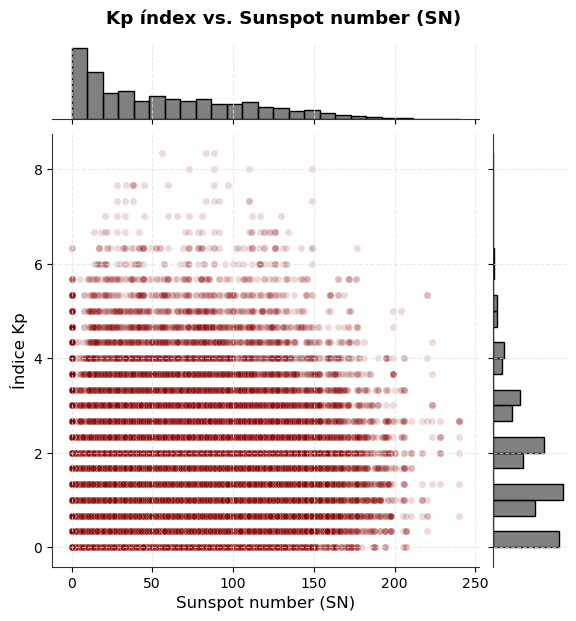

In [117]:
## Tareas mínimas
### Scatter plot

# Extraemos solo la fecha (sin horas) de nuestro df_kp
df_kp['date'] = df_kp['datetime'].dt.normalize()

# Cruzamos df_kp con la columna SN de df_geom usando 'date' como llave
df_scatter = pd.merge(df_kp, df_geom[['date', 'SN']], on='date', how='left')

# Verificamos que no haya nulos generados en el cruce
df_scatter = df_scatter.dropna(subset=['Kp', 'SN'])

# 2. Visualización: Scatter plot Kp vs. SN usando JointGrid
g = sns.jointplot(
    data=df_scatter, 
    x="SN", 
    y="Kp", 
    kind="scatter",
    color="darkred",  
    alpha=0.15,     # Transparencia alta, Kp forma franjas horizontales densas
    s=25,           # Tamaño de puntos
    marginal_kws=dict(bins=25, fill=True, color="#4A4A4A", alpha=0.7) # Histograma gris oscuro
)


# 3. Ajustes estéticos finales
g.set_axis_labels("Sunspot number (SN)", "Índice Kp", fontsize=12)
g.figure.suptitle("Kp índex vs. Sunspot number (SN)", fontweight="bold", y=1.03)

plt.show()

In [14]:
# Ap histogram


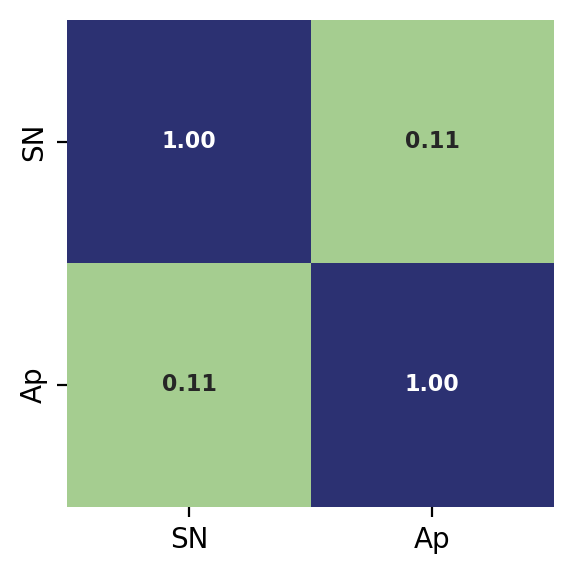

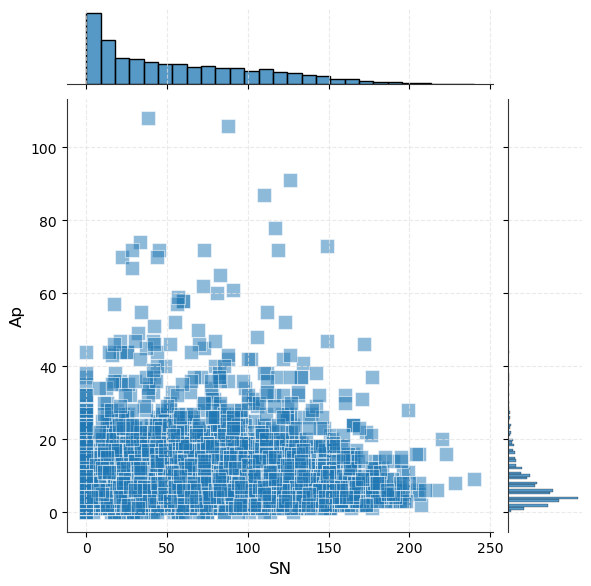

In [ ]:
covMatrix = df_geom[["SN", "Ap"]].corr()
plt.figure(figsize=(3, 3), dpi = 200)
ax = sns.heatmap(
    covMatrix,
    annot=True,
    fmt=".2f",
    cmap="crest",
    cbar=False,
    square=True,
    annot_kws={"size": 8, "weight": "bold"},
)
ax.grid(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
plt.tight_layout()

# sns.jointplot(data=df_geom, x="SN", y="Ap", kind="hist")
sns.jointplot(data=df_geom, x="SN", y="Ap", marker="s", s=100,alpha=0.5)


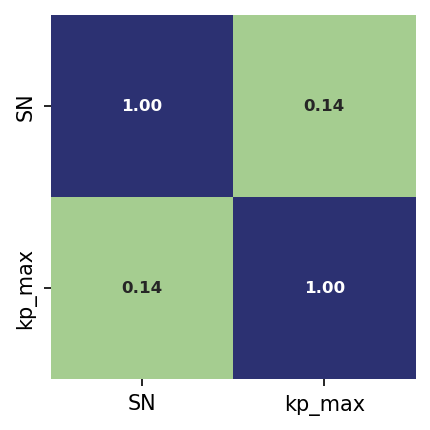

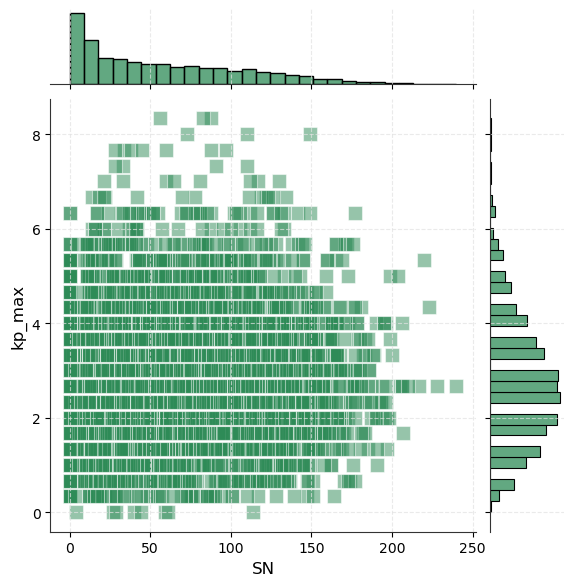

In [16]:
# Analizando maximos
df_geom['kp_max'] = df_geom[kp_cols].max(axis = 1)

corrMatrixKpSN = df_geom[['SN', 'kp_max']].corr()
plt.figure(figsize=(3,3), dpi = 150)


ax = sns.heatmap(
    corrMatrixKpSN,
    annot=True,
    fmt=".2f",
    cmap="crest",
    cbar=False,
    square=True,
    annot_kws={"size": 8, "weight": "bold"},
)
ax.grid(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
plt.tight_layout()

sns.jointplot(data=df_geom, x="SN", y="kp_max", marker="s", s=100, alpha=0.5, color="#2E8B57")
plt.show()

### Gamma, Lognormal and weibull for Kp >5 (storm)

In [17]:
# Gamma, Lognormal and weibull for Kp >5 (storm)
# tomamos solo los valores de kp en tormenta 
kp_storm = df_kp["Kp"][df_kp["Kp"]>=5].dropna().values + 0.005 # +0.05 to avoid 5.0 values due to 'gamma' requires that 5 < (x - loc)/scale  < inf f 

FLOC = 5
threshold = 5

# model fit, ignoramos el retorno de loc
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(kp_storm, floc=FLOC)
sigma_logn, loc_logn, scale_logn   = stats.lognorm.fit(kp_storm, floc=FLOC)
c_weibull, loc_weibull, scale_weibull = stats.weibull_min.fit(kp_storm, floc=FLOC)


print("Fit Params:")
print(f" - Gamma    : shape = {shape_gamma:.4f} / scale = {scale_gamma:.4f}")
print(f" - Lognormal: sigma = {sigma_logn:.4f} / scale = {scale_logn:.4f}")
print(f" - Weibull  : shape = {c_weibull:.4f} / scale = {scale_weibull:.4f}")

# , hacemos 
ll_gamma   = stats.gamma.logpdf(kp_storm, a=shape_gamma, loc=FLOC, scale=scale_gamma).sum()
ll_lognorm = stats.lognorm.logpdf(kp_storm, s=sigma_logn, loc=FLOC, scale=scale_logn).sum()
ll_weibull = stats.weibull_min.logpdf(kp_storm, c=c_weibull, loc=FLOC, scale=scale_weibull).sum() 

# validamos con AIC: nro de params=2 para cada modelo
k=2
n= len(kp_storm)

aic_gamma = -2 * ll_gamma + 2*k
aic_weibull = -2 * ll_weibull + 2*k
aic_lognorm = -2 * ll_lognorm + 2*k

print("\nAIC for each model:")
print(f" - Gamma    : {aic_gamma:.4f}")
print(f" - Lognormal: {aic_lognorm:.4f}")
print(f" - Weibull: {aic_weibull:.4f}")

# el modelo Lognormal es el que mejor se ajusta a los datos

x_fit = np.linspace(5.1, kp_storm.max(), 200)

Fit Params:
 - Gamma    : shape = 0.4413 / scale = 1.3133
 - Lognormal: sigma = 2.3881 / scale = 0.1335
 - Weibull  : shape = 0.5682 / scale = 0.4044

AIC for each model:
 - Gamma    : 192.4103
 - Lognormal: 393.7636
 - Weibull: 260.2075



El modelo que mejor se ajusta es: Gamma


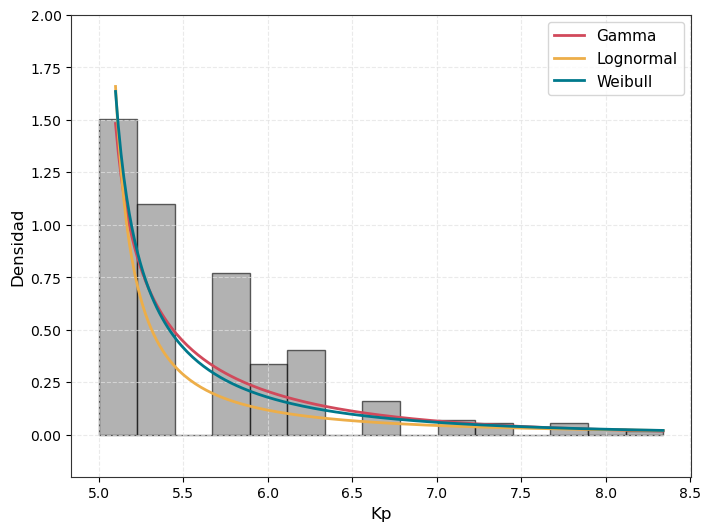

In [18]:
fig = plt.figure(figsize=(8,6
                         ))
plt.hist(kp_storm, bins=15, edgecolor="black", facecolor="gray", density=True, alpha=0.6)

plt.plot(x_fit, stats.gamma.pdf(x_fit, a=shape_gamma, loc=FLOC, scale=scale_gamma),
        color="#D1495B", lw=2, label="Gamma")
plt.plot(x_fit, stats.lognorm.pdf(x_fit, s=sigma_logn, loc=FLOC,scale=scale_logn),
        color="#EDAE49", lw=2, label="Lognormal")
plt.plot(x_fit, stats.weibull_min.pdf(x_fit, c=c_weibull, loc=FLOC,scale=scale_weibull),
        color="#00798C", lw=2, label="Weibull")

plt.ylim(-0.2,2)
plt.legend()
plt.ylabel("Densidad")
plt.xlabel("Kp")
model_names = ["Gamma", "Lognormal", "Weibull"]
print(f"\nEl modelo que mejor se ajusta es: {model_names[np.argmin([aic_gamma,aic_lognorm, aic_weibull])]}")
plt.show()

### proporcion de horas en tormen
ta 

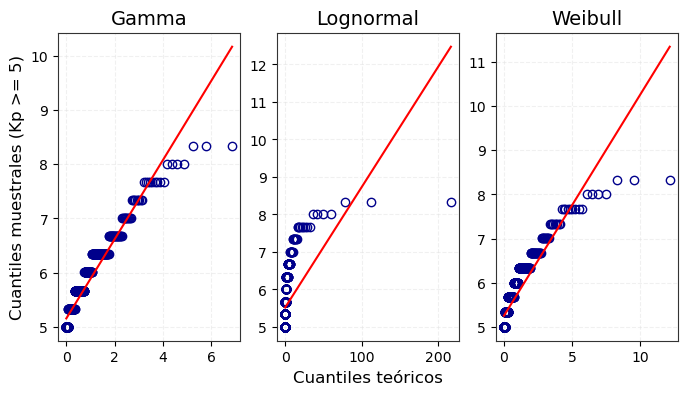

In [19]:
fig = plt.figure(figsize=(8, 4))

ax = plt.subplot(131)
stats.probplot(kp_storm, dist=stats.gamma, sparams=(shape_gamma, 0, scale_gamma), plot=plt,)
plt.title(f'Gamma')
plt.xlabel('')
plt.ylabel('Cuantiles muestrales (Kp >= 5)')
plt.grid(alpha=0.5)
ax.get_lines()[0].set_marker('o')
ax.get_lines()[0].set_markerfacecolor('none')
ax.get_lines()[0].set_markeredgecolor('darkblue')

ax = plt.subplot(132)
stats.probplot(kp_storm, dist=stats.lognorm, sparams=(sigma_logn, 0, scale_logn), plot=plt,)
plt.title(f'Lognormal')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('')
plt.grid(alpha=0.5)
ax.get_lines()[0].set_marker('o')
ax.get_lines()[0].set_markerfacecolor('none')
ax.get_lines()[0].set_markeredgecolor('darkblue')

ax = plt.subplot(133)
stats.probplot(kp_storm, dist=stats.weibull_min, sparams=(c_weibull, 0, scale_weibull), plot=plt,)
plt.title(f'Weibull')
plt.xlabel('')
plt.ylabel('')
plt.grid(alpha=0.5)
ax.get_lines()[0].set_marker('o')
# ax.get_lines()[0].set_ylim(4.5, )
ax.get_lines()[0].set_markerfacecolor('none')
ax.get_lines()[0].set_markeredgecolor('darkblue')

plt.show()

### Proporción anual de horas con tormenta y su IC 95 %

In [20]:
# from simport 
from statsmodels.stats.proportion import proportion_confint as proportion_ic

In [21]:
# IC for each year Wilson
# flag para tormenta
df_kp["storm"] = (df_kp["Kp"]>=5).astype(int)
# df_kp.head()
# n_hours: whole time (h) in a year, x_storm: hours of storm
# these are factor of 3h 
kp_anual = df_kp.groupby("year").agg(n_hours=("storm", "count"), x_storm=("storm", "sum")).reset_index()
kp_anual.head()
kp_anual["ratio"] = kp_anual["x_storm"]/kp_anual["n_hours"]
kp_anual
# IC for each year
wilson_low, wilson_high = proportion_ic(
                                        count=kp_anual["x_storm"],
                                        nobs=kp_anual["n_hours"],
                                        alpha=0.05, 
                                        method="wilson"
                                        )


In [22]:
kp_anual["wilson_low"] = wilson_low
kp_anual["wilson_high"] = wilson_high

In [23]:
# IC for each Bottstrap
np.random.seed(42)
B = 2500
btp_low = []
btp_high = []
plow = 2.5
phigh = 97.5

for year in kp_anual["year"]:
    _year_data = df_kp.loc[df_kp["year"]==year, "storm"].values #data of the year
    n = len(_year_data)
    proportions_boot = []
    for k in range(B):
        _sample = np.random.choice(_year_data, size=n, replace=True)
        proportions_boot.append(_sample.mean())
    proportions_boot = np.sort(proportions_boot)
    # percentiles [2.5, 97.5]
    _low = np.percentile(proportions_boot, plow)
    _high = np.percentile(proportions_boot, phigh)
    btp_low.append(_low)
    btp_high.append(_high)

kp_anual["boot_low"] = btp_low
kp_anual["boot_high"] = btp_high

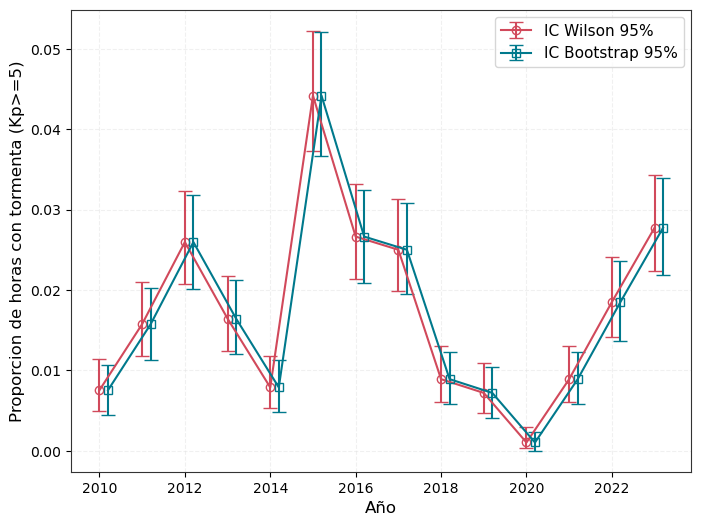

In [24]:
fig = plt.figure(figsize=(8, 6))
plt.errorbar(kp_anual["year"], kp_anual["ratio"], yerr=[kp_anual["ratio"]-kp_anual["wilson_low"],kp_anual["wilson_high"]-kp_anual["ratio"]],
            fmt="o-", color="#D1495B", capsize=5, label="IC Wilson 95%", mfc="none")
plt.errorbar(kp_anual["year"]+0.2, kp_anual["ratio"], yerr=[kp_anual["ratio"]-kp_anual["boot_low"],kp_anual["boot_high"]-kp_anual["ratio"]],
            fmt="s-", color="#00798C", capsize=5, label="IC Bootstrap 95%", mfc="none")
plt.xlabel("Año")
plt.ylabel("Proporcion de horas con tormenta (Kp>=5)")
plt.legend()
plt.grid(ls="--", alpha=0.5)
plt.show()

IC con Bootstrap  y Wilson asumen obseracoens independientes. la dependencia tempriral reduce la cantidad efectiva de datos (¿usar block bootstrap?)

## Tareas mínimas
### Prueba de Mann Whitney Kp, máximo vs mínimo solar y d de Cohen 

### 3. Hay diferencia significativa de Kp entre verano e invierno boreales?

In [122]:
anios_maximo = [2013, 2014, 2015] 
anios_minimo = [2018, 2019, 2020]

kp_maximo = df_kp[df_kp['year'].isin(anios_maximo)]['Kp'].dropna()
kp_minimo = df_kp[df_kp['year'].isin(anios_minimo)]['Kp'].dropna()

# Prueba de Mann Whitney
stat_mw, p_valor_mw = stats.mannwhitneyu(kp_maximo, kp_minimo, alternative='two-sided')

# Calculo d de Cohen
n1, n2 = len(kp_maximo), len(kp_minimo)
var1, var2 = np.var(kp_maximo, ddof=1), np.var(kp_minimo, ddof=1)

# Desviacion standar agrupada
sd_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

d_cohen = (np.mean(kp_maximo) - np.mean(kp_minimo)) / sd_pooled

print("--- Prueba Mann-Whitney U (Kp: Máximo vs Mínimo Solar) ---")
print(f"Estadístico U : {stat_mw}")
print(f"Valor p       : {p_valor_mw:.4e}")
print(f"d de Cohen    : {d_cohen:.4f}")

if p_valor_mw < 0.05:
    print("Conclusión    : Hay una diferencia estadísticamente significativa en el índice Kp entre el máximo y mínimo solar.")
else:
    print("Conclusión    : No hay evidencia suficiente para afirmar una diferencia en el índice Kp.")

--- Prueba Mann-Whitney U (Kp: Máximo vs Mínimo Solar) ---
Estadístico U : 46280170.0
Valor p       : 1.8831e-123
d de Cohen    : 0.3748
Conclusión    : Hay una diferencia estadísticamente significativa en el índice Kp entre el máximo y mínimo solar.


--- Comparación de Kp: Verano vs Invierno Boreal ---
--En el boxplot observamos que en el invierno boreal, Kp tiene un corte en < 7, mientras que,
--en el verano boreal, la cola de la distribución es más extensa (Kp > 7)
--Los eventos más extremos son más frecuentes en esa ventana de tiempo.
N Verano: 10304 observaciones | Mediana: 1.333
N Invierno: 10104 observaciones | Mediana: 1.333

Prueba de Mann-Whitney U: Estadístico = 54722785.00, p-value = 1.9137e-10
Tamaño del efecto (d de Cohen): 0.0680

Conclusión: Se rechaza la hipótesis nula. Existe una diferencia estadísticamente significativa en el índice Kp entre el verano y el invierno boreales.


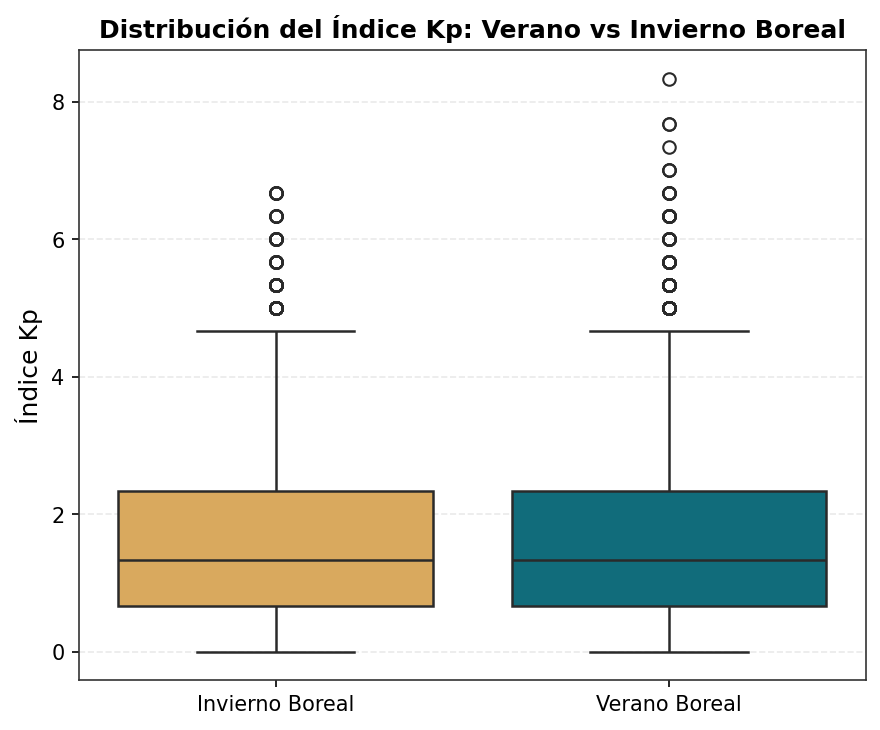

In [25]:
# Considerando : Verano boreal   -> Junio, Julio y Agosto (meses 6, 7 y 8)
#              : Invierno boreal -> Diciembre, Enero, Febrero (meses 12, 1 y 2)

mesesVerano   = [6, 7, 8]
mesesInvierno = [12, 1, 2]

verano   = df_kp[df_kp["datetime"].dt.month.isin(mesesVerano)]["Kp"].dropna()
invierno = df_kp[df_kp["datetime"].dt.month.isin(mesesInvierno)]["Kp"].dropna()

stat_mw, p_val_mw = stats.mannwhitneyu(verano, invierno, alternative='two-sided')

# Hipotesis no parametrica (Man - Withney U)
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pool_sd = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pool_sd

d_cohen = cohen_d(verano, invierno)

print("--- Comparación de Kp: Verano vs Invierno Boreal ---")
print("--En el boxplot observamos que en el invierno boreal, Kp tiene un corte en < 7, mientras que,")
print("--en el verano boreal, la cola de la distribución es más extensa (Kp > 7)")
print("--Los eventos más extremos son más frecuentes en esa ventana de tiempo.")
print(f"N Verano: {len(verano)} observaciones | Mediana: {verano.median():.3f}")
print(f"N Invierno: {len(invierno)} observaciones | Mediana: {invierno.median():.3f}")
print(f"\nPrueba de Mann-Whitney U: Estadístico = {stat_mw:.2f}, p-value = {p_val_mw:.4e}")
print(f"Tamaño del efecto (d de Cohen): {d_cohen:.4f}")

if p_val_mw < 0.05:
    print("\nConclusión: Se rechaza la hipótesis nula. Existe una diferencia estadísticamente significativa en el índice Kp entre el verano y el invierno boreales.")
else:
    print("\nConclusión: No se rechaza la hipótesis nula. No hay evidencia de una diferencia significativa")

df_seasons = df_kp[df_kp["datetime"].dt.month.isin(mesesVerano + mesesInvierno)].copy()
df_seasons["Temporada"] = np.where(df_seasons["datetime"].dt.month.isin(mesesVerano), "Verano Boreal", "Invierno Boreal")

plt.figure(figsize=(6, 5), dpi=150)

# Boxplot limpio
sns.boxplot(
    data=df_seasons, 
    x="Temporada", 
    y="Kp",
    hue="Temporada",
    legend=False,
    palette=["#EDAE49", "#00798C"], 
    linewidth=1.2
)

plt.title("Distribución del Índice Kp: Verano vs Invierno Boreal", fontsize=12, fontweight="bold")
plt.ylabel("Índice Kp")
plt.xlabel("")
plt.tight_layout()
plt.show()

#df_kp

### 4. ¿Puede predecirse Kp a partir de variables solares retardadas (sunspot, F10.7)?

In [26]:
# MODEL AREGRESIVO: RETRASOSdf_geom
df_geom["F10.7adj"]

0        72.7
1        75.4
2        73.8
3        70.6
4        74.3
        ...  
5108    144.5
5109    141.8
5110    138.2
5111    135.1
5112    141.4
Name: F10.7adj, Length: 5113, dtype: float64

In [27]:
lags = [1, 3, 5]
daily_solar = df_geom[["date", "SN", "F10.7adj"]].drop_duplicates(subset="date").copy()
daily_solar = daily_solar.sort_values("date").reset_index(drop=True)


Text(0, 0.5, 'SFU (10⁻²² W m⁻² Hz⁻¹)')

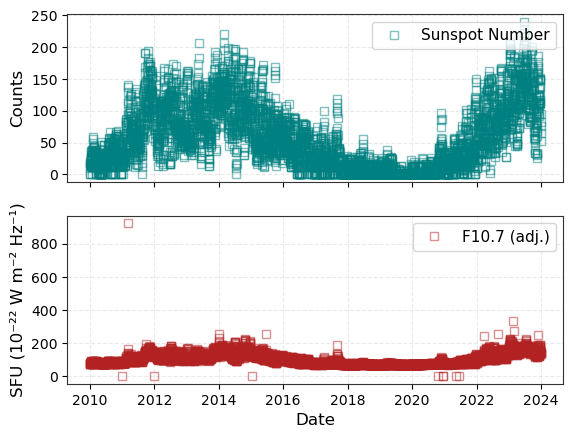

In [28]:
fig, axs = plt.subplots(2, sharex=True)
ax1 = axs[0]
ax1.plot(daily_solar["date"], daily_solar["SN"], lw=0, marker="s", mfc="none", 
               mec="teal", alpha=0.5, label="Sunspot Number")
ax1.set_ylabel("Counts")
ax1.legend(loc="upper right")
ax2 = axs[1]
ax2.plot(daily_solar["date"], daily_solar["F10.7adj"], lw=0, marker="s", mfc="none", 
               mec="firebrick", alpha=0.5, label="F10.7 (adj.)")
ax2.legend(loc="upper right")
ax2.set_xlabel("Date")
ax2.set_ylabel("SFU (10⁻²² W m⁻² Hz⁻¹)")

In [29]:
df_kp["date"] = df_kp["datetime"].dt.date

In [30]:
# lags = [1, 3, 5, 7, 14, 21, 27, 30]
lags = np.arange(1,31,2)
for lag in lags:
    daily_solar[f"SN_lag{lag}"] = daily_solar["SN"].shift(lag)
    daily_solar[f"F10.7_lag{lag}"] = daily_solar["F10.7adj"].shift(lag)


df = df_geom.merge(daily_solar, on="date", how="left", suffixes=('', '_daily'))
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
df = df.dropna()
df.head()

,year,month,day,days,days_m,BSR,dB,Kp_00,Kp_03,Kp_06,...,SN_lag23,F10.7_lag23,SN_lag25,F10.7_lag25,SN_lag27,F10.7_lag27,SN_lag29,F10.7_lag29,month_sin,month_cos
29,2010,1,30,28519,28519.5,2408,17,2.000,2.0,1.000,...,0.0,75.5,10.0,74.3,16.0,73.8,18.0,72.7,0.500000,0.866025
30,2010,1,31,28520,28520.5,2408,18,2.333,1.0,0.333,...,15.0,74.9,0.0,74.7,15.0,70.6,21.0,75.4,0.500000,0.866025
31,2010,2,1,28521,28521.5,2408,19,1.333,0.0,1.667,...,15.0,79.0,0.0,75.5,10.0,74.3,16.0,73.8,0.866025,0.500000
32,2010,2,2,28522,28522.5,2408,20,3.000,2.0,1.000,...,22.0,81.6,15.0,74.9,0.0,74.7,15.0,70.6,0.866025,0.500000
33,2010,2,3,28523,28523.5,2408,21,3.000,1.0,2.667,...,37.0,86.3,15.0,79.0,0.0,75.5,10.0,74.3,0.866025,0.500000


In [31]:
# verificamos correlacion para cada retardo entre kp y las otras variables
# lags = [1, 3, 7, 14, 27] # cantidad de dias historicos
corr_sn= [df["kp_max"].corr(df[f"SN_lag{lag}"]) for lag in lags]
corr_f107= [df["kp_max"].corr(df[f"F10.7_lag{lag}"]) for lag in lags]
lag_maxcorr = lags[np.argmax(corr_sn)]
print(f"Lag de máxima correlación: {lag_maxcorr}")


Lag de máxima correlación: 3


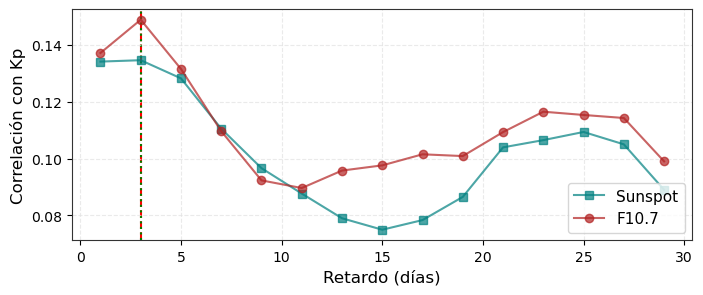

In [32]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lags, corr_sn, 's-', color="teal",label='Sunspot', alpha=0.7)
ax.plot(lags, corr_f107, 'o-', color="firebrick",label='F10.7', alpha=0.7)
# ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Retardo (días)')
ax.set_ylabel('Correlación con Kp')
# ax.set_title('Correlación : Kp vs. [SN, F10.7]')
ax.legend(loc="lower right")
# Max correlation Lag
max_corr_sn = lags[np.argmax(corr_sn)]
max_corr_f107 = lags[np.argmax(corr_f107)]
ax.axvline(max_corr_sn, color="red", ls="--", zorder=0)
ax.axvline(max_corr_sn, color="green", ls=":", zorder=0)
plt.show()

In [33]:
xvars = [f"SN_lag{lag_maxcorr}", f"F10.7_lag{lag_maxcorr}", "month_sin", "month_cos"]
X = df[xvars]
X = sm.add_constant(X)
Y = df["kp_max"]

# implementamos el modelo OLS
model = sm.OLS(Y, X).fit()

hac_cov = cov_hac(model, nlags=5)
hac_se = np.sqrt(np.diag(hac_cov))
result_table = pd.DataFrame({
    'Variable': model.params.index,
    'coef'    : model.params.values,
    'SE_OLS'  : model.bse.values,
    'SE_HAC'  : hac_se,
    't_HAC'   : model.params.values / hac_se,
    'p_HAC'   : 2 * (1-stats.t.cdf(np.abs(model.params.values/hac_se),model.df_resid))
})
print("------------ RAW SUMMARY --------------")
print(model.summary())
print("----------------- HAC -----------------")
print(result_table.round(4))

------------ RAW SUMMARY --------------
                            OLS Regression Results                            
Dep. Variable:                 kp_max   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     29.42
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           3.18e-24
Time:                        19:08:55   Log-Likelihood:                -8535.1
No. Observations:                5084   AIC:                         1.708e+04
Df Residuals:                    5079   BIC:                         1.711e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

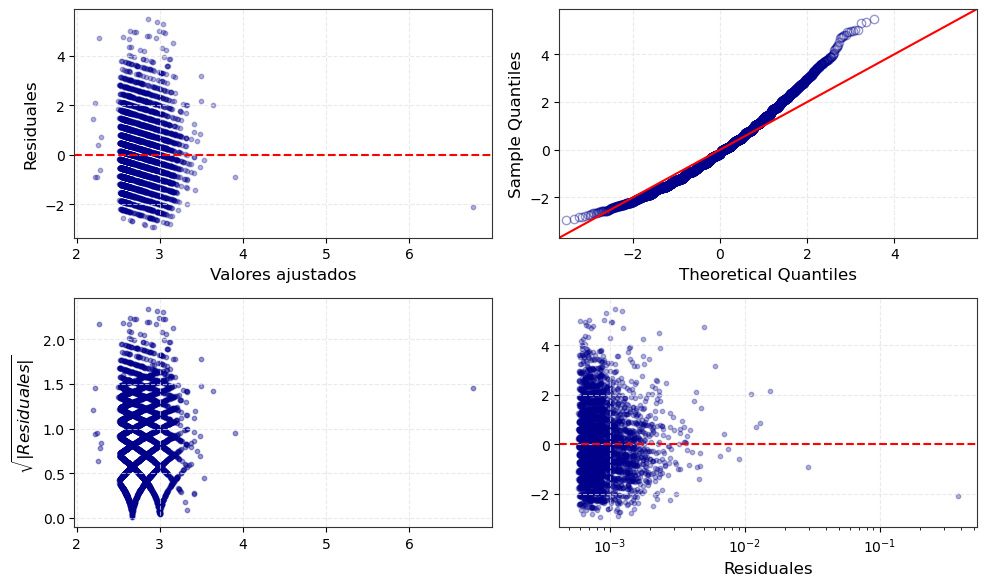

In [34]:
fig, axs = plt.subplots(2,2, figsize=(10, 6))
ax = axs[0,0]
ax.scatter(model.fittedvalues, model.resid, alpha=0.3, s=10, color="darkblue")
ax.axhline(0, color="red", ls="--")
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Residuales')
ax = axs[0,1]
sm.qqplot(model.resid, line="45", ax=ax,markerfacecolor="none", markeredgecolor="darkblue", alpha=0.4)

ax = axs[1,0]
ax.scatter(model.fittedvalues, np.sqrt(np.abs(model.resid)), alpha=0.4, s=10, color="darkblue")
ax.set_ylabel(r"$\sqrt{|Residuales|}$")
# ax.set_xscale("log")

ax = axs[1,1]
influence = model.get_influence()
ax.scatter(influence.hat_matrix_diag, model.resid, alpha=0.3, s=10, color="darkblue")
ax.axhline(0, color="red", ls="--")
ax.set_xscale("log")
ax.set_xlabel("Leverage")
ax.set_xlabel("Residuales")
plt.tight_layout()

In [35]:
# test formal de suspuestos bresuch pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ["LM statistic", "LM p-value", "F statistic", "F p-value"]
bp_results = dict(zip(labels, bp_test))
print("Breusch Pagan Test:")
print(bp_results)

Breusch Pagan Test:
{'LM statistic': 18.775888179498345, 'LM p-value': 0.0008697557105999755, 'F statistic': 4.706738238942336, 'F p-value': 0.0008619479124608416}


In [36]:
# cross validation
nsplits = 5
kf = KFold(n_splits=nsplits, shuffle=True, random_state=42)
tscv = TimeSeriesSplit(n_splits=nsplits)
rmse_scores = []
r2_scores   = []
rmse_scores_ts = []
r2_scores_ts   = []
print("Corss Validation N_splits=",nsplits)
for fold, ((train_idx, test_idx),(train_idx_ts, test_idx_ts)) in enumerate(zip(kf.split(X),tscv.split(X)),1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    model_fold = sm.OLS(Y_train, X_train).fit()
    Y_pred = model_fold.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2 = 1 - np.sum((Y_test- Y_pred)**2)/np.sum((Y_test-Y_test.mean())**2)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    print(f"KFold {fold} : RMSE = {rmse:2.4f}, R2 = {r2:2.4f}\t", end="")
    # kfold
    X_train, X_test = X.iloc[train_idx_ts], X.iloc[test_idx_ts]
    Y_train, Y_test = Y.iloc[train_idx_ts], Y.iloc[test_idx_ts]
    model_fold = sm.OLS(Y_train, X_train).fit()
    Y_pred = model_fold.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2 = 1 - np.sum((Y_test- Y_pred)**2)/np.sum((Y_test-Y_test.mean())**2)
    rmse_scores_ts.append(rmse)
    r2_scores_ts.append(r2)
    print(f"TS split {fold} : RMSE = {rmse:2.4f}, R2 = {r2:2.4f}")
    
print()
print(f"Overall:\n  KFold\n   MEAN RMSE = {np.mean(rmse_scores)}\n   MEAN R2 = {np.mean(r2_scores)}")
print(f"  TimeSeries Split\n   MEAN RMSE = {np.mean(rmse_scores_ts)}\n   MEAN R2 = {np.mean(r2_scores_ts)}")

Corss Validation N_splits= 5
KFold 1 : RMSE = 1.2747, R2 = 0.0177	TS split 1 : RMSE = 1.3217, R2 = -0.0149
KFold 2 : RMSE = 1.2420, R2 = 0.0234	TS split 2 : RMSE = 1.5259, R2 = -0.3309
KFold 3 : RMSE = 1.2978, R2 = 0.0204	TS split 3 : RMSE = 1.2985, R2 = -0.0021
KFold 4 : RMSE = 1.3117, R2 = 0.0229	TS split 4 : RMSE = 1.2120, R2 = -0.1497
KFold 5 : RMSE = 1.3676, R2 = 0.0005	TS split 5 : RMSE = 1.2875, R2 = -0.0337

Overall:
  KFold
   MEAN RMSE = 1.2987375507047623
   MEAN R2 = 0.016981618178519908
  TimeSeries Split
   MEAN RMSE = 1.3291547837124342
   MEAN R2 = -0.10624093163509048


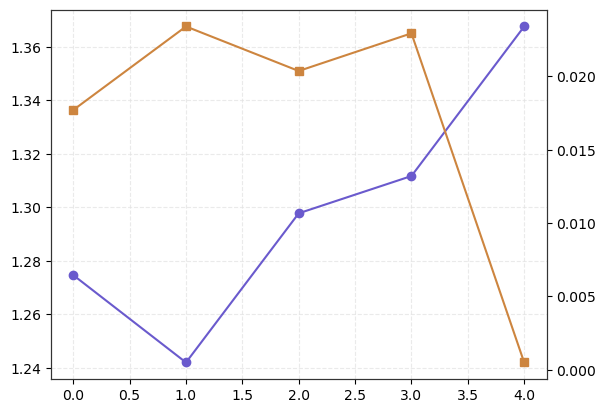

In [37]:
fig = plt.figure()
ax = plt.subplot()
plt.plot(rmse_scores,"o-",color="slateblue")
ax2 = ax.twinx()
plt.plot(r2_scores, "s-", color="peru")
plt.grid(False)

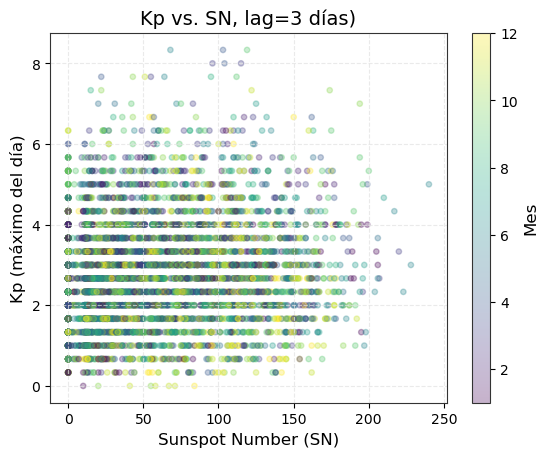

In [38]:
fig, ax = plt.subplots()
ax.scatter(df['SN_lag3'], df['kp_max'], alpha=0.3, s=15, c=df['month'], cmap='viridis')
ax.set_xlabel('Sunspot Number (SN)')
ax.set_ylabel('Kp (máximo del día)')
ax.set_title('Kp vs. SN, lag=3 días)')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Mes')
plt.show()

In [39]:
X_full = df[['kp_max_lag1', 'sunspot_lag3', 'F10.7_lag3', 'month_sin', 'month_cos']]
X_full = sm.add_constant(X_full)

model_full = sm.OLS(y, X_full).fit()
print("\n" + "=" * 60)
print("MODELO 2: Persistencia + variables solares")
print("=" * 60)
print(model_full.summary())

# HAC para modelo full
hac_cov_full = cov_hac(model_full, nlags=5)
hac_se_full = np.sqrt(np.diag(hac_cov_full))
results_full = pd.DataFrame({
    'Variable': model_full.params.index,
    'Coef': model_full.params.values,
    'SE_OLS': model_full.bse.values,
    'SE_HAC': hac_se_full,
    't_HAC': model_full.params.values / hac_se_full,
    'p_HAC': 2 * (1 - stats.t.cdf(np.abs(model_full.params.values / hac_se_full), model_full.df_resid))
})
print("\n--- HAC (Modelo Full) ---")
print(results_full.round(4))


KeyError: "['kp_max_lag1', 'sunspot_lag3'] not in index"